# Bus bunching on line 4 Gullmarsplan to Radiohuset

1. Data preparation
2. Descriptive analysis
3. Shared ML setup with features, train/test split, models
4. Prediction 1: is the bus bunched within 3 stops?
5. Prediction 2: does holding the bus prevent bunching?
6. Model diagnostics

# 1. Data preparation

In [51]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load the data (northbound to Radiohuset, 06:00–22:00)**

In [52]:
import numpy as np
import pandas as pd

path = '/content/drive/MyDrive/Data202409/line4_bus_weekdays_202409_202411.csv.gz'

columns = ['date', 'direction_id', 'trip_id', 'VehicleID', 'stop_sequence', 'observed_stop_id',
           'scheduled_arrival_time_sfm', 'observed_arrival_time_sfm',
           'observed_arrival_delay', 'scheduled_departure_time_sfm', 'observed_departure_time_sfm',
           'stop_headsign']
df = pd.read_csv(path, sep=';', usecols=columns)

df['trip_id'] = df['trip_id'].astype(str)

# Remove rows without an observed arrival time
df = df.dropna(subset=['observed_arrival_time_sfm'])

# Keep buses scheduled between 06:00 (6*3600 s) and 22:00 (22*3600 s)
df = df[(df['scheduled_arrival_time_sfm'] >= 6*3600) &
        (df['scheduled_arrival_time_sfm'] < 22*3600)].copy()

# Keep only the northbound direction
df = df[df['direction_id'] == 0].copy()
print(f"Days: {df['date'].nunique()}  Rows and columns: {df.shape}")
display(df.groupby('direction_id')['stop_headsign'].value_counts())

Days: 65  Rows and columns: (156297, 12)


,,count
direction_id,stop_headsign,
0,Radiohuset,156297


**Bunching label**

For each bus: A bus is **bunched** when the real gap is less than half the planned gap (headway ratio < 0.5).

In [53]:
# Buses in timetable order at each stop
df = df.sort_values(['date', 'observed_stop_id', 'scheduled_arrival_time_sfm'])
same_stop = df.groupby(['date', 'observed_stop_id'])

# Planned gap to the bus in front (seconds)
df['scheduled_headway'] = same_stop['scheduled_arrival_time_sfm'].diff()
# Real gap with sign: negative = this bus arrived BEFORE the bus in front (overtaking)
df['signed_observed_gap'] = same_stop['observed_arrival_time_sfm'].diff()
df['observed_headway'] = df['signed_observed_gap'].abs()
# Negative = the buses arrived closer together than planned
df['headway_difference'] = df['observed_headway'] - df['scheduled_headway']

# Remove rows without a bus in front
df = df.dropna(subset=['scheduled_headway', 'observed_headway'])
df = df[df['scheduled_headway'] > 0].copy()

# Headway ratio: 1 = as planned, below 0.5 = bunched
df['headway_ratio'] = df['observed_headway'] / df['scheduled_headway']
df['bunching'] = (df['headway_ratio'] < 0.5).astype(int)

# Hour of the day and dwell time (seconds the bus stands at the stop)
df['hour'] = df['scheduled_arrival_time_sfm'] // 3600
df['dwell_time'] = df['observed_departure_time_sfm'] - df['observed_arrival_time_sfm']

**Stop names**

In [54]:
stop_names = [
    'Gullmarsplan', 'Skanstull', 'Eriksdal', 'Rosenlund', 'Södra station',
    'Hornsgatan/Rosenlundsgatan', 'Zinkensdamm', 'Varvsgatan', 'Hornstull',
    'Västerbroplan', 'Fridhemsplan', 'Fleminggatan', 'S:t Eriksplan',
    'Dalagatan', 'Odenplan', 'Stadsbiblioteket', 'Roslagsgatan',
    'Valhallavägen', 'Östra station', 'Stadion', 'Musikhögskolan',
    'Värtavägen', 'Banérgatan', 'Garnisonen', 'Radiohuset',
]

stop_names_by_sequence = dict(enumerate(stop_names, start=1))
df['stop_label'] = df['stop_sequence'].map(stop_names_by_sequence).fillna('Unknown stop')

# The final dataset used in the rest of the notebook: each bus's stops in route order
df_all = df.sort_values(['date', 'trip_id', 'stop_sequence']).reset_index(drop=True)

df_all[['date', 'trip_id', 'stop_label', 'scheduled_headway', 'observed_headway',
        'headway_ratio', 'bunching']].head(10)

,date,trip_id,stop_label,scheduled_headway,observed_headway,headway_ratio,bunching
0,20240902,14010000664276866,Odenplan,960.0,797.0,0.830208,0
1,20240902,14010000664276866,Stadsbiblioteket,960.0,887.0,0.923958,0
2,20240902,14010000664276866,Roslagsgatan,960.0,891.0,0.928125,0
3,20240902,14010000664276866,Valhallavägen,960.0,887.0,0.923958,0
4,20240902,14010000664276866,Östra station,960.0,931.0,0.969792,0
5,20240902,14010000664276866,Stadion,960.0,951.0,0.990625,0
6,20240902,14010000664276866,Musikhögskolan,960.0,967.0,1.007292,0
7,20240902,14010000664276866,Värtavägen,960.0,963.0,1.003125,0
8,20240902,14010000664276866,Banérgatan,960.0,968.0,1.008333,0
9,20240902,14010000664276866,Garnisonen,960.0,954.0,0.993750,0


# 2. Descriptive analysis

Share of bunched bus-stops: 9.0 %


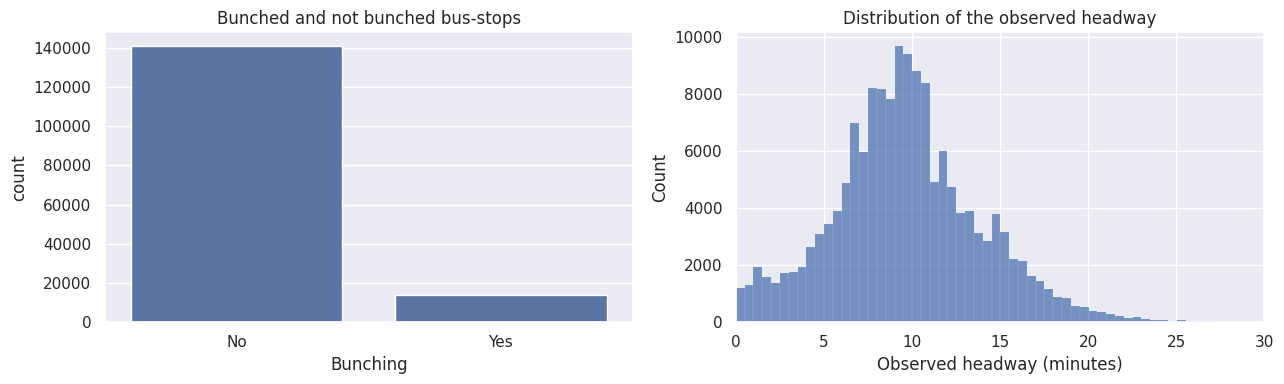

In [55]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# How common is bunching, and how are the real headways distributed?
print(f"Share of bunched bus-stops: {df_all['bunching'].mean() * 100:.1f} %")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df_all, x='bunching', ax=axes[0])
axes[0].set_xticks([0, 1], ['No', 'Yes'])
axes[0].set_xlabel('Bunching')
axes[0].set_title('Bunched and not bunched bus-stops')
sns.histplot(df_all['observed_headway'] / 60, binwidth=0.5, ax=axes[1])
axes[1].set_xlim(0, 30)
axes[1].set_xlabel('Observed headway (minutes)')
axes[1].set_title('Distribution of the observed headway')
plt.tight_layout()
plt.show()

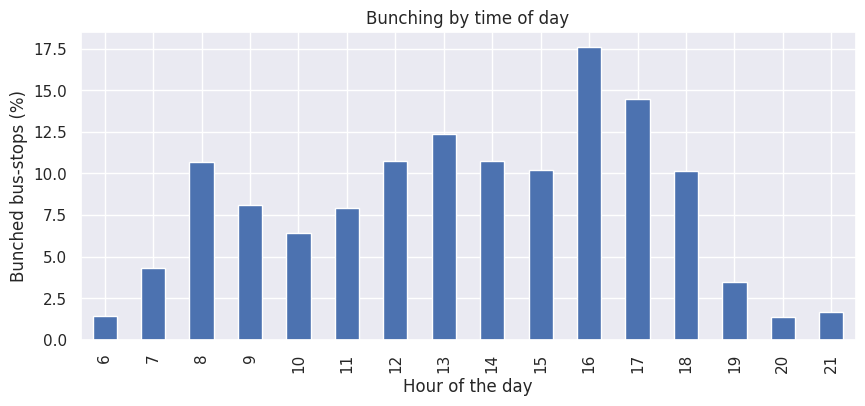

In [56]:
# Bunching by time of day
share_by_hour = df_all.groupby('hour')['bunching'].mean() * 100
share_by_hour.plot(kind='bar', figsize=(10, 4))
plt.xlabel('Hour of the day')
plt.ylabel('Bunched bus-stops (%)')
plt.title('Bunching by time of day')
plt.show()

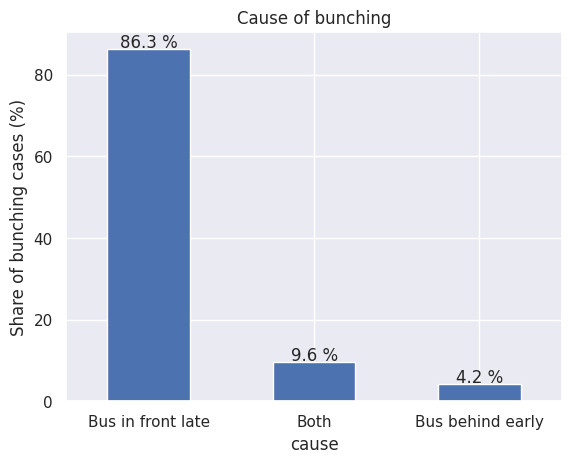

In [57]:
# Cause of each bunching case: which bus made the gap shrink?
# If one bus caused at least 2/3 of the lost gap it gets the blame, otherwise the cause is 'Both'.
d = df_all.sort_values(['date', 'observed_stop_id', 'scheduled_arrival_time_sfm'])
d['front_bus_delay'] = d.groupby(['date', 'observed_stop_id'])['observed_arrival_delay'].shift(1)
causes = d[d['bunching'] == 1].dropna(subset=['front_bus_delay', 'observed_arrival_delay']).copy()

front_part = causes['front_bus_delay']
behind_part = -causes['observed_arrival_delay']
share_front = front_part / (front_part + behind_part)

causes['cause'] = 'Both'
causes.loc[share_front >= 2/3, 'cause'] = 'Bus in front late'
causes.loc[share_front <= 1/3, 'cause'] = 'Bus behind early'
no_loss = (front_part + behind_part) <= 0  # rare: the gap did not shrink, blame the larger part
causes.loc[no_loss & (front_part >= behind_part), 'cause'] = 'Bus in front late'
causes.loc[no_loss & (front_part < behind_part), 'cause'] = 'Bus behind early'

cause_share = causes['cause'].value_counts(normalize=True).reindex(
    ['Bus in front late', 'Both', 'Bus behind early']) * 100
ax = cause_share.plot(kind='bar')
for i, value in enumerate(cause_share):
    ax.text(i, value + 0.5, f'{value:.1f} %', ha='center')
plt.ylabel('Share of bunching cases (%)')
plt.title('Cause of bunching')
plt.xticks(rotation=0)
plt.show()

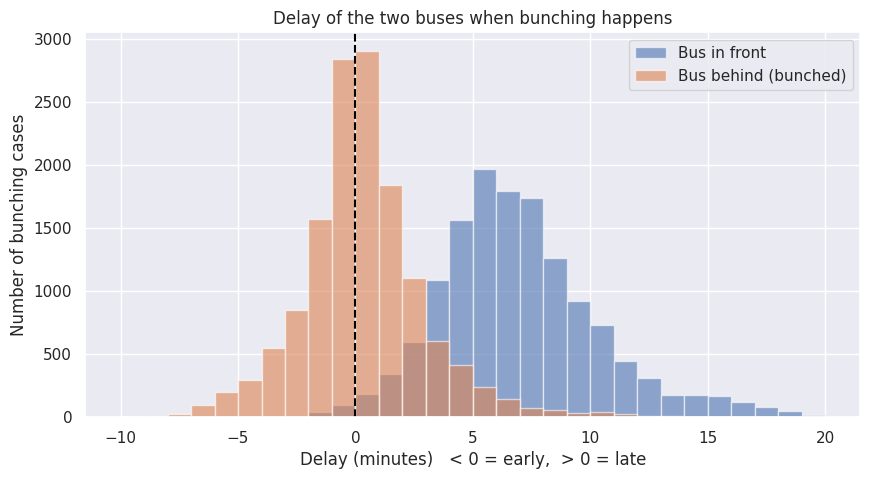

In [58]:
# Delay of the two buses when bunching happens
bunched = causes.copy()
bunched['front_bus_delay_min'] = bunched['front_bus_delay'] / 60
bunched['own_delay_min'] = bunched['observed_arrival_delay'] / 60

# One bar per minute, from 10 min early to 20 min late
bins = range(-10, 21)

plt.figure(figsize=(10, 5))
plt.hist(bunched['front_bus_delay_min'], bins=bins, alpha=0.6, label='Bus in front')
plt.hist(bunched['own_delay_min'], bins=bins, alpha=0.6, label='Bus behind (bunched)')
plt.axvline(0, color='black', linestyle='--')   # 0 = on time
plt.xlabel('Delay (minutes)   < 0 = early,  > 0 = late')
plt.ylabel('Number of bunching cases')
plt.title('Delay of the two buses when bunching happens')
plt.legend()
plt.show()

**Where does bunching start?**

A bus *starts* bunching on a section when it was not bunched at the previous stop and is bunched at the next one. The heatmap shows the number of new bunching events per hour and stop (all 65 days together).

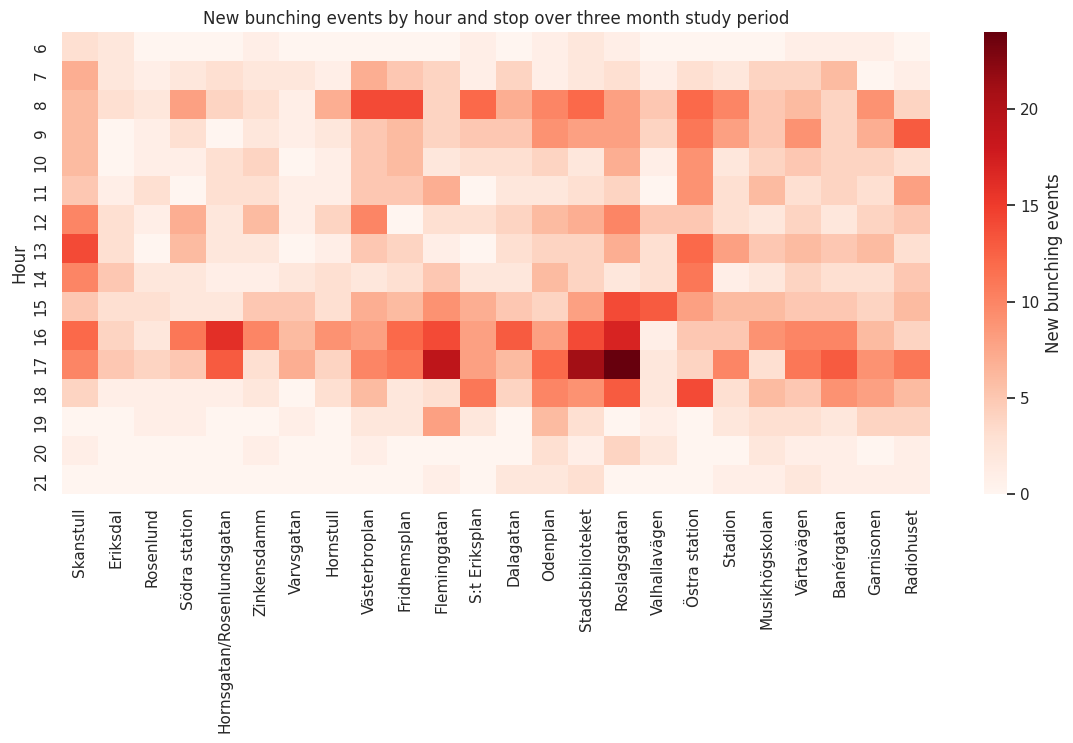

In [59]:
# A bus starts bunching at a stop when it was not bunched at the stop just before and is bunched here
same_trip = df_all.groupby(['date', 'trip_id'])
df_all['previous_bunching'] = same_trip['bunching'].shift(1)
df_all['previous_stop_sequence'] = same_trip['stop_sequence'].shift(1)
df_all['bunching_start'] = ((df_all['bunching'] == 1) & (df_all['previous_bunching'] == 0)).astype(int)

# Buses that can start bunching: not bunched at the stop just before
possible = df_all[(df_all['previous_bunching'] == 0) &
                  (df_all['stop_sequence'] - df_all['previous_stop_sequence'] == 1)].copy()

# New bunching events (number of buses that start bunching) by hour and stop, all 65 days
heat = possible.pivot_table(index='hour', columns='stop_sequence', values='bunching_start', aggfunc='sum')
plt.figure(figsize=(14, 6))
sns.heatmap(heat, cmap='Reds', cbar_kws={'label': 'New bunching events'})
plt.xticks(np.arange(len(heat.columns)) + 0.5, [stop_names_by_sequence[s] for s in heat.columns], rotation=90)
plt.xlabel('')
plt.ylabel('Hour')
plt.title('New bunching events by hour and stop over three month study period')
plt.show()

# 3. Shared ML setup

Everything in this section is written once and used by both predictions (section 4 and 5).

**Features**

All features use only information that is known in real time when the bus arrives at the stop:
- about the same bus at the previous stop (its delay and the delay it gained on the last section),
- about the bus in front at this stop (its delay and dwell time),
- about the bus in front **further down the route**: how many stops ahead it is, its own headway ratio there and how much delay it is gaining (`front_bus_stops_ahead`, `front_bus_latest_ratio`, `front_bus_delay_gain`),
- historical averages per stop and hour, calculated on the training days only.

For the bus in front further down the route we use `pd.merge_asof`. For every bus it looks up the **last** stop that the bus in front had reached **before** this bus arrives at its stop. It matches on time and only allows earlier times, so the model only gets information that was really available at that moment.

In [60]:
# Features: only information that is known when the bus arrives at the stop
# (dwell_time at THIS stop is only known when the bus leaves, so the dwell time at the previous stop is used)

# About the same bus (previous stop)
df_all = df_all.sort_values(['date', 'trip_id', 'stop_sequence'])
same_trip = df_all.groupby(['date', 'trip_id'])
df_all['arrival_delay'] = df_all['observed_arrival_delay']
df_all['upstream_stop_delay'] = same_trip['observed_arrival_delay'].shift(1)
df_all['delay_change'] = df_all['arrival_delay'] - df_all['upstream_stop_delay']
df_all['upstream_dwell_time'] = same_trip['dwell_time'].shift(1)
df_all['travel_time_previous_section'] = (df_all['observed_arrival_time_sfm'] - same_trip['observed_departure_time_sfm'].shift(1))
df_all['headway_ratio_change'] = df_all['headway_ratio'] - same_trip['headway_ratio'].shift(1)

# About the bus in front (same stop)
df_all = df_all.sort_values(['date', 'observed_stop_id', 'scheduled_arrival_time_sfm'])
same_stop = df_all.groupby(['date', 'observed_stop_id'])
df_all['previous_bus_delay'] = same_stop['observed_arrival_delay'].shift(1)
df_all['front_bus_delay_change'] = same_stop['delay_change'].shift(1)
df_all['front_bus_headway_ratio'] = same_stop['headway_ratio'].shift(1)
df_all['front_bus_dwell_time'] = same_stop['dwell_time'].shift(1)

# About the bus in front further down the route (its real-time position).
# The bus in front has usually already passed the next stops, so its latest stop shows
# what happens on the stretch where bunching may happen.

# Step 1: the trip of the bus in front (the bus scheduled just before at the same stop)
df_all = df_all.sort_values(['date', 'observed_stop_id', 'scheduled_arrival_time_sfm'])
df_all['front_trip_id'] = df_all.groupby(['date', 'observed_stop_id'])['trip_id'].shift(1)

# Step 2: "left" table = for every bus: the trip of the bus in front and the time this bus arrives here
left = (df_all[['date', 'front_trip_id', 'observed_arrival_time_sfm']].dropna().reset_index()
        .rename(columns={'front_trip_id': 'trip_id'}).sort_values('observed_arrival_time_sfm'))
# The trip ids must have the same type in both tables
left['trip_id'] = left['trip_id'].astype(df_all['trip_id'].dtype)

# Step 3: "right" table = every arrival of every bus: time, stop, delay and headway ratio
right = (df_all[['date', 'trip_id', 'observed_arrival_time_sfm', 'stop_sequence',
                 'observed_arrival_delay', 'headway_ratio']]
         .rename(columns={'observed_arrival_time_sfm': 'front_time', 'stop_sequence': 'front_latest_stop',
                          'observed_arrival_delay': 'front_latest_delay', 'headway_ratio': 'front_latest_ratio'})
         .sort_values('front_time'))

# Step 4: merge_asof finds, for every bus, the LAST arrival of the bus in front (same date and trip)
# BEFORE this bus arrives here. allow_exact_matches=False: only strictly earlier times (no future information)
latest = pd.merge_asof(left, right, left_on='observed_arrival_time_sfm', right_on='front_time',
                       by=['date', 'trip_id'], allow_exact_matches=False).set_index('index')

# Step 5: the three new features
df_all['front_bus_stops_ahead'] = latest['front_latest_stop'] - df_all['stop_sequence']  # how many stops ahead it is
df_all['front_bus_latest_ratio'] = latest['front_latest_ratio']  # its own headway ratio at that stop
df_all['front_bus_delay_gain'] = latest['front_latest_delay'] - df_all['previous_bus_delay']  # delay it gained since here

# Historical aggregates per stop and hour, from the TRAINING days only (the last 15 days are test days)
train_days = sorted(df_all['date'].unique())[:-15]
hist = (df_all[df_all['date'].isin(train_days)]
        .groupby(['stop_sequence', 'hour'])[['bunching', 'dwell_time']].mean()
        .rename(columns={'bunching': 'hist_bunching_rate', 'dwell_time': 'hist_dwell_time'}))
df_all = df_all.drop(columns=hist.columns, errors='ignore').join(hist, on=['stop_sequence', 'hour'])

df_all = df_all.sort_values(['date', 'trip_id', 'stop_sequence'])

# ONE feature list for both predictions
features = ['headway_ratio', 'scheduled_headway', 'arrival_delay', 'previous_bus_delay',
            'delay_change', 'front_bus_dwell_time', 'hist_dwell_time', 'stop_sequence', 'hour',
            'front_bus_stops_ahead', 'front_bus_latest_ratio', 'front_bus_delay_gain']

# The hold models (section 5) use the same features WITHOUT the three features about the bus in front
# further down the route: the holding simulation cannot update them after a hold, so they would be outdated there.
hold_features = [f for f in features if f not in ['front_bus_stops_ahead', 'front_bus_latest_ratio', 'front_bus_delay_gain']]

df_all[features].describe().round(1)

,headway_ratio,scheduled_headway,arrival_delay,previous_bus_delay,delay_change,front_bus_dwell_time,hist_dwell_time,stop_sequence,hour,front_bus_stops_ahead,front_bus_latest_ratio,front_bus_delay_gain
count,154672.0,154672.0,154672.0,153047.0,148299.0,153040.0,154672.0,154672.0,154672.0,152966.0,152966.0,152966.0
mean,1.0,588.2,104.7,104.9,-1.8,32.1,31.9,13.0,13.3,3.6,1.0,-41.7
std,0.4,273.4,224.8,225.6,63.7,39.8,17.8,7.2,4.3,2.4,0.4,127.3
min,0.0,300.0,-3068.0,-3068.0,-3285.0,0.0,6.4,1.0,6.0,-23.0,0.0,-3518.0
25%,0.8,480.0,-3.0,-4.0,-30.0,17.0,20.8,7.0,9.0,2.0,0.8,-113.0
50%,1.0,600.0,65.0,65.0,-3.0,25.0,26.6,13.0,14.0,3.0,1.0,-15.0
75%,1.2,600.0,170.0,171.0,30.0,38.0,38.0,19.0,17.0,5.0,1.2,32.0
max,8.9,13800.0,8549.0,8549.0,3464.0,3506.0,107.1,25.0,21.0,24.0,7.1,3502.0


In [61]:
# ONE train/test split by day for both predictions:
# the last 15 weekdays (three full weeks) are test days, the rest are training days
dates = sorted(df_all['date'].unique())
test_dates = dates[-15:]
print(f"Training days: {len(dates) - 15}  Test days: {test_dates[0]} - {test_dates[-1]}")

Training days: 50  Test days: 20241111 - 20241129


**The models**

Four model types from the course are compared: logistic regression (the baseline), a decision tree, a random forest and XGBoost. All of them give the few positive cases extra weight (`class_weight='balanced'`), because bunching and helpful holds are rare.

Some features are missing for some buses (for example, at the first stop there is no previous stop). Logistic regression and the sklearn trees cannot handle missing values, and logistic regression also needs scaled features. `make_pipeline` puts these preparation steps and the model together into one object: the median and the scaling are learned from the training data when the model is trained, and every later prediction (on the test days and inside the holding simulation) automatically uses the same steps.


In [62]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ONE dictionary with the four model types, used for both predictions.
# make_pipeline joins the preparation steps and the model into one object, so the same steps are
# used when the model is trained AND every time it predicts (also inside the holding simulation).
# The few positive cases get extra weight (class_weight='balanced').
models = {
    # Logistic regression: fill missing values with the median, scale the features, then the model
    'Logistic regression': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                                         LogisticRegression(class_weight='balanced', max_iter=1000)),
    # Decision tree: fill missing values (trees do not need scaling), at most 6 questions deep
    'Decision tree': make_pipeline(SimpleImputer(strategy='median'),
                                   DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)),
    # Random forest: fill missing values, 100 trees with at least 20 buses in every leaf
    'Random forest': make_pipeline(SimpleImputer(strategy='median'),
                                   RandomForestClassifier(n_estimators=100, min_samples_leaf=20,
                                                          class_weight='balanced', n_jobs=-1, random_state=42)),
    # XGBoost handles missing values itself, so it needs no pipeline
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
}

# Decision thresholds to test (the default 0.5 gives many false alarms with class weighting)
thresholds = np.arange(0.05, 0.96, 0.05)

**`compare_models`: one function for all model comparisons**

The same steps are used for every model and for both predictions, so they are written once as a function instead of being repeated:

1. The training days are split: the first training days are used to train the model, the last 10 training days (validation days) to choose the decision threshold.
2. Every model is trained, and the threshold with the best F1 on the validation days is chosen.
3. The best model is the one with the highest F1 on the **validation days**. The test days are only used for the final evaluation: AUC, recall, precision and F1.
4. If a title is given, the ROC curves of all models are drawn in one figure.

The function returns a results table (best model first) and the trained models with their thresholds.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [63]:
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve

def compare_models(train, test, target, model_list=models, title=None, feature_list=None):
    """Train every model, choose its threshold and test it.

    - trained on the training days except the last 10
    - threshold = best F1 on the last 10 training days (validation days)
    - best model = highest F1 on the validation days (the test days are only used to report the scores)
    - tested on the test days
    Returns a results table (best model first) and {model name: (trained model, threshold)}.
    """
    # The features to use (default: the shared feature list)
    cols = features if feature_list is None else feature_list

    # Split the training days: the last 10 days are validation days (used to choose the threshold)
    val_days = sorted(train['date'].unique())[-10:]
    fit_part = train[~train['date'].isin(val_days)]
    val_part = train[train['date'].isin(val_days)]

    # Features (X) and target (y) for the three parts
    X_train, y_train = fit_part[cols], fit_part[target]
    X_val, y_val = val_part[cols], val_part[target]
    X_test, y_test = test[cols], test[target]

    # Results table (one row per model) and the trained models
    rows, fitted = [], {}
    if title:
        # One figure for the ROC curves of all models
        plt.figure(figsize=(7, 5))
    for name, model in model_list.items():
        # Make a fresh, untrained copy of the model
        model = clone(model)
        # Train the model on the first training days
        if isinstance(model, XGBClassifier):
            # XGBoost has no class_weight, so the extra weight is given with sample_weight
            model.fit(X_train, y_train, sample_weight=compute_sample_weight('balanced', y_train))
        else:
            model.fit(X_train, y_train)

        # Choose the threshold with the best F1 on the validation days
        y_probs_val = model.predict_proba(X_val)[:, 1]
        t_best = thresholds[np.argmax([f1_score(y_val, y_probs_val >= t) for t in thresholds])]
        # F1 on the validation days with this threshold (used to choose the best model)
        f1_val = f1_score(y_val, y_probs_val >= t_best)

        # Predict the probabilities on the test days and turn them into 0/1 with the threshold
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs >= t_best).astype(int)
        # Save the scores of this model on the test days
        rows.append({'Model': name, 'Threshold': t_best, 'Validation F1': f1_val, 'AUC': roc_auc_score(y_test, y_probs),
                     'Recall': recall_score(y_test, y_pred),
                     'Precision': precision_score(y_test, y_pred),
                     'F1': f1_score(y_test, y_pred)})
        # Save the trained model and its threshold
        fitted[name] = (model, t_best)

        if title:
            # ROC curve of this model, as in Exercise 3
            fpr, tpr, _ = roc_curve(y_test, y_probs)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {rows[-1]["AUC"]:.3f})')

    if title:
        # Add the random guess line and show the ROC curves
        plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
        plt.xlabel('False positive rate')
        plt.ylabel('True positive rate')
        plt.title(title)
        plt.legend(loc='lower right')
        plt.show()

    # Results table with the best model first: highest F1 on the VALIDATION days
    # (the other columns are the scores on the test days, for the final evaluation only)
    results = pd.DataFrame(rows).set_index('Model').sort_values('Validation F1', ascending=False)
    return results, fitted

# 4. Prediction 1: is the bus bunched within 3 stops?

Only buses that are **not** bunched now are used: the question is whether bunching can be seen coming.

In [64]:
def make_ahead_data(k):
    """Buses that are not bunched now, with the target: bunched at ANY of the next k stops (1 = yes)."""
    d = df_all.sort_values(['date', 'trip_id', 'stop_sequence']).copy()
    same_trip = d.groupby(['date', 'trip_id'])
    # 1 if the bus is bunched at stop +1, +2, ... or +k
    d['bunching_ahead'] = pd.concat([same_trip['bunching'].shift(-j) for j in range(1, k + 1)], axis=1).max(axis=1)
    # Check that the next k stops really are the next k stops (some stops may be missing)
    d['stops_ahead'] = same_trip['stop_sequence'].shift(-k) - d['stop_sequence']
    d = d[(d['stops_ahead'] == k) & (d['bunching'] == 0)].copy()
    d['bunching_ahead'] = d['bunching_ahead'].astype(int)
    return d

ahead_data = make_ahead_data(3)
# Training days and test days
ahead_train = ahead_data[~ahead_data['date'].isin(test_dates)]
ahead_test = ahead_data[ahead_data['date'].isin(test_dates)]
print(f"Train: {len(ahead_train)}  Test: {len(ahead_test)}")
print(f"Bunched within 3 stops: {ahead_data['bunching_ahead'].mean() * 100:.1f} %")

Train: 96518  Test: 27925
Bunched within 3 stops: 3.1 %


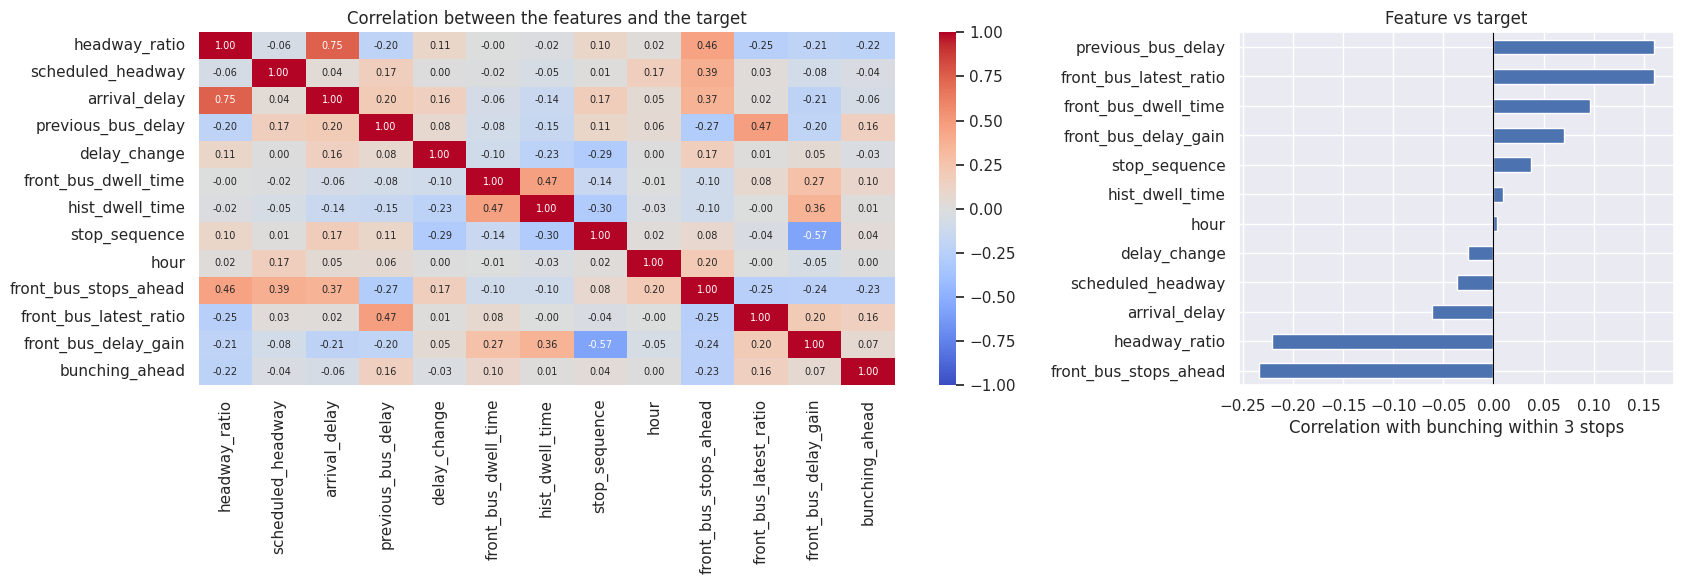

In [65]:
# Correlations between the features and the target (bunched within 3 stops)
corr_matrix = ahead_data[features + ['bunching_ahead']].corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [2, 1]})
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7}, ax=axes[0])
axes[0].set_title('Correlation between the features and the target')
corr_matrix['bunching_ahead'].drop('bunching_ahead').sort_values().plot(kind='barh', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation with bunching within 3 stops')
axes[1].set_title('Feature vs target')
plt.tight_layout()
plt.show()

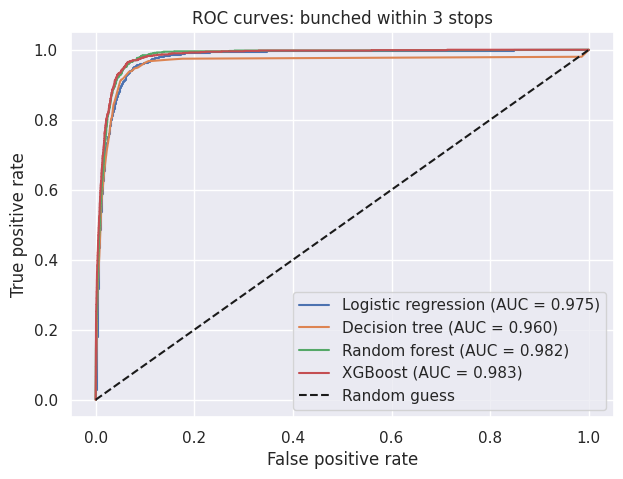

,Threshold,Validation F1,AUC,Recall,Precision,F1
Model,,,,,,
XGBoost,0.90,0.627,0.983,0.697,0.618,0.655
Random forest,0.75,0.609,0.982,0.745,0.552,0.634
Logistic regression,0.90,0.594,0.975,0.615,0.574,0.594
Decision tree,0.85,0.552,0.960,0.842,0.437,0.576


Best model: XGBoost, threshold: 0.90


In [66]:
# Compare all models
ahead_results, ahead_models = compare_models(ahead_train, ahead_test, 'bunching_ahead', title='ROC curves: bunched within 3 stops')
display(ahead_results.round(3))

best_ahead = ahead_results.index[0]
bunch_model, bunch_threshold = ahead_models[best_ahead]
print(f"Best model: {best_ahead}, threshold: {bunch_threshold:.2f}")

In [67]:
# Hyperparameter tuning of the best model with GridSearchCV
from sklearn.model_selection import GridSearchCV, GroupKFold

param_grids = {
    'Logistic regression': {'logisticregression__C': [0.01, 0.1, 1, 10]},
    'Decision tree': {'decisiontreeclassifier__max_depth': [4, 6, 8, 10],
                      'decisiontreeclassifier__min_samples_leaf': [1, 20, 100]},
    'Random forest': {'randomforestclassifier__max_depth': [6, 10, None],
                      'randomforestclassifier__min_samples_leaf': [5, 20, 50]},
    'XGBoost': {'max_depth': [3, 4, 6], 'n_estimators': [100, 200, 400], 'learning_rate': [0.05, 0.1]},
}

val_days = sorted(ahead_train['date'].unique())[-10:]
fit_part = ahead_train[~ahead_train['date'].isin(val_days)]
val_part = ahead_train[ahead_train['date'].isin(val_days)]

# XGBoost gets the extra weight on the bunching class via sample_weight (the others have class_weight)
fit_params = {}
if best_ahead == 'XGBoost':
    fit_params = {'sample_weight': compute_sample_weight('balanced', fit_part['bunching_ahead'])}

# The grid for the best model type
param_grid = param_grids[best_ahead]

grid_search = GridSearchCV(clone(models[best_ahead]), param_grid, cv=GroupKFold(n_splits=5),
                    scoring='average_precision', n_jobs=-1)
grid_search.fit(fit_part[features], fit_part['bunching_ahead'], groups=fit_part['date'], **fit_params)
best_params = grid_search.best_params_
print(f"Best settings for {best_ahead}: {best_params}")

# Threshold for the tuned model (best F1 on the validation days), then the test days
tuned = grid_search.best_estimator_
y_probs_val = tuned.predict_proba(val_part[features])[:, 1]
t_tuned = thresholds[np.argmax([f1_score(val_part['bunching_ahead'], y_probs_val >= t) for t in thresholds])]
# F1 of the tuned model on the validation days (used for the decision below)
f1_val_tuned = f1_score(val_part['bunching_ahead'], y_probs_val >= t_tuned)

# Test days: only reported, not used for the decision
X_test, y_test = ahead_test[features], ahead_test['bunching_ahead']
y_probs = tuned.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= t_tuned).astype(int)

before = ahead_results.loc[best_ahead]
tuning_results = pd.DataFrame({
    'Before tuning': before[['Validation F1', 'Threshold', 'AUC', 'Recall', 'Precision', 'F1']],
    'After tuning': [f1_val_tuned, t_tuned, roc_auc_score(y_test, y_probs), recall_score(y_test, y_pred),
                     precision_score(y_test, y_pred), f1_score(y_test, y_pred)]}).T
display(tuning_results.round(3))

# Use the tuned model from here on if it is better on the VALIDATION days.
# bunch_model_type = the (untrained) model settings for prediction 1, used again in the k = 1-5 loop and
# the diagnostics. The shared 'models' dictionary is NOT changed, so the hold models in section 5 keep their settings.
bunch_model_type = models[best_ahead]
if tuning_results.loc['After tuning', 'Validation F1'] > tuning_results.loc['Before tuning', 'Validation F1']:
    bunch_model, bunch_threshold = tuned, t_tuned
    bunch_model_type = clone(tuned)
    print('The tuned model is used from here on.')
else:
    print('Tuning did not improve F1 on the validation days, the original model is kept.')

Best settings for XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


,Validation F1,Threshold,AUC,Recall,Precision,F1
Before tuning,0.627,0.9,0.983,0.697,0.618,0.655
After tuning,0.634,0.9,0.982,0.662,0.641,0.651


The tuned model is used from here on.


              precision    recall  f1-score   support

           0       0.99      0.99      0.99     27026
           1       0.64      0.66      0.65       899

    accuracy                           0.98     27925
   macro avg       0.81      0.82      0.82     27925
weighted avg       0.98      0.98      0.98     27925



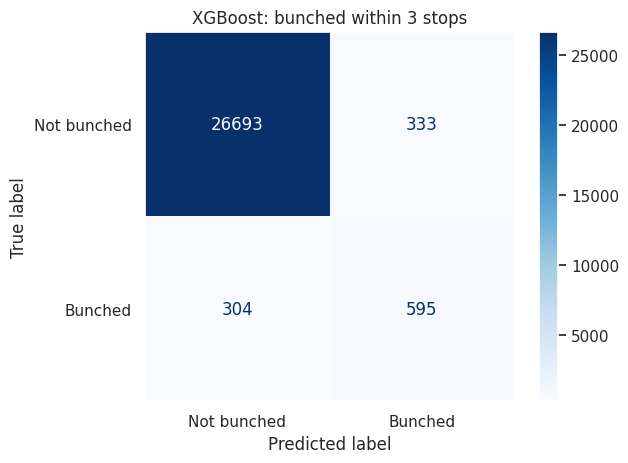

Best model (XGBoost) saved to /content/drive/MyDrive/best_model_bunching.joblib, decision threshold: 0.90
Loaded model gives the same predictions on the test days: True


In [68]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Best model on the test days
X_test = ahead_test[features]
y_test = ahead_test['bunching_ahead']

# Predict the probabilities and turn them into 0/1 with the chosen threshold
y_probs = bunch_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= bunch_threshold).astype(int)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Not bunched', 'Bunched']).plot(cmap='Blues')
plt.title(f'{best_ahead}: bunched within 3 stops')
plt.grid(False)
plt.show()

# Save the best-trained model to an external file on Google Drive, so it can be loaded again without retraining.
# The file holds everything needed to make predictions: the trained model (incl. its preprocessing pipeline),
# the decision threshold and the feature list in the right order.
import joblib

model_path = '/content/drive/MyDrive/best_model_bunching.joblib'
joblib.dump({'model': bunch_model, 'model_type': best_ahead,
             'threshold': bunch_threshold, 'features': features}, model_path)
print(f"Best model ({best_ahead}) saved to {model_path}, decision threshold: {bunch_threshold:.2f}")

# Check: load the file again and make sure it gives the same predictions as the model in memory
saved = joblib.load(model_path)
same = np.array_equal(saved['model'].predict_proba(X_test[saved['features']])[:, 1] >= saved['threshold'], y_pred)
print(f"Loaded model gives the same predictions on the test days: {same}")

**Which features predict bunching?**

Permutation importance works for every model type: each feature is shuffled in turn, and the bigger the drop in score, the more the model relies on that feature.

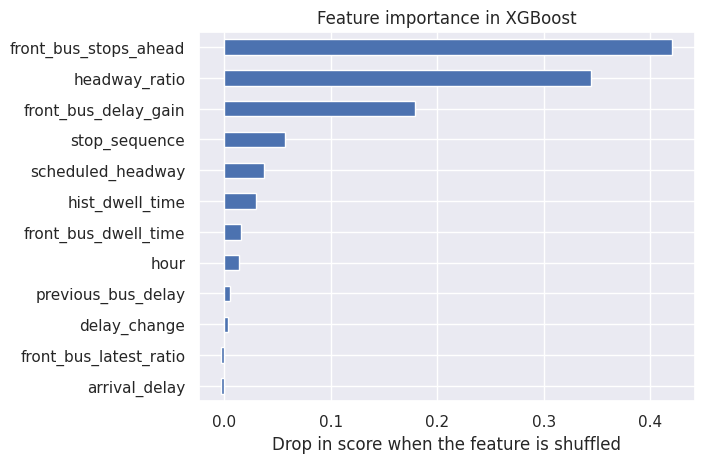

In [69]:
from sklearn.inspection import permutation_importance

# Permutation importance on the VALIDATION days (the last 10 training days, not used to train the model)
val_days = sorted(ahead_train['date'].unique())[-10:]
ahead_val = ahead_train[ahead_train['date'].isin(val_days)]
sample = ahead_val.sample(min(20000, len(ahead_val)), random_state=42)
X_val, y_val = sample[features], sample['bunching_ahead']
perm = permutation_importance(bunch_model, X_val, y_val,
                              scoring='average_precision', n_repeats=3, random_state=42)
importance = pd.Series(perm.importances_mean, index=features).sort_values()
importance.plot(kind='barh')
plt.xlabel('Drop in score when the feature is shuffled')
plt.title(f'Feature importance in {best_ahead}')
plt.show()

**How far ahead can bunching be predicted? (1 to 5 stops)**

The best model from above, trained again for each k with the same steps (no full model comparison needed).

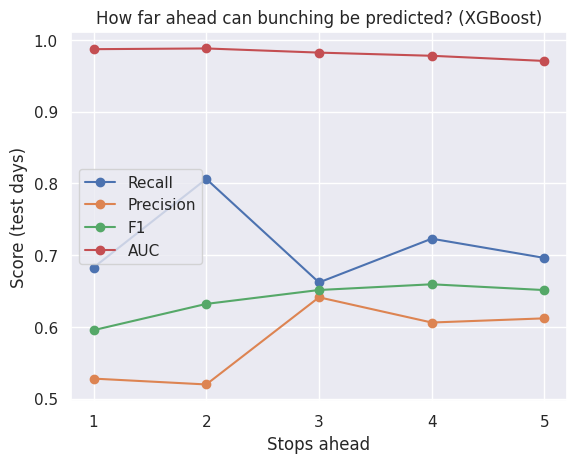

,Bunching share (%),Threshold,Validation F1,AUC,Recall,Precision,F1
Stops ahead,,,,,,,
1,1.234,0.90,0.577,0.987,0.683,0.528,0.595
2,2.246,0.80,0.631,0.988,0.806,0.520,0.632
3,3.219,0.90,0.634,0.982,0.662,0.641,0.651
4,4.179,0.85,0.624,0.978,0.723,0.606,0.659
5,5.080,0.85,0.608,0.971,0.696,0.612,0.651


In [70]:
rows = []
for k in range(1, 6):
    # Dataset for k stops ahead, split into training days and test days
    data_k = make_ahead_data(k)
    train_k = data_k[~data_k['date'].isin(test_dates)]
    test_k = data_k[data_k['date'].isin(test_dates)]
    res, _ = compare_models(train_k, test_k, 'bunching_ahead', {best_ahead: bunch_model_type})
    rows.append({'Stops ahead': k, 'Bunching share (%)': test_k['bunching_ahead'].mean() * 100,
                 **res.iloc[0].to_dict()})
scores_ahead = pd.DataFrame(rows).set_index('Stops ahead')

scores_ahead[['Recall', 'Precision', 'F1', 'AUC']].plot(marker='o')
plt.xticks(range(1, 6))
plt.ylabel('Score (test days)')
plt.title(f'How far ahead can bunching be predicted? ({best_ahead})')
plt.show()
scores_ahead.round(3)

# 5. Prediction 2: does holding the bus prevent bunching?

**Target from the simulation:** for every bus that is too close (headway ratio < 0.5), would holding it 60 s at this stop avoid bunching later on the route?

Holding bus A moves all its later arrivals 60 s later. At each later stop this changes two gaps: A's gap to the bus in front grows (good), and the gap of the bus behind A shrinks (bad). The value of the hold = bunched bus-stops avoided minus bunched bus-stops created. Each hold is valued on its own (no other bus is held).

In [71]:
H = 60  # hold length (seconds)

hv = df_all.sort_values(['date', 'observed_stop_id', 'scheduled_arrival_time_sfm']).copy()
same_stop = hv.groupby(['date', 'observed_stop_id'])
# The bus behind (next bus at the same stop)
hv['behind_gap'] = same_stop['signed_observed_gap'].shift(-1)
hv['behind_scheduled_headway'] = same_stop['scheduled_headway'].shift(-1)
hv['behind_bunching'] = same_stop['bunching'].shift(-1)

# Bunching at each stop if the bus had been held H seconds at an earlier stop
hv = hv.sort_values(['date', 'trip_id', 'stop_sequence'])
own_new = ((hv['signed_observed_gap'] + H).abs() < 0.5 * hv['scheduled_headway']).astype(int)
behind_new = ((hv['behind_gap'] - H).abs() < 0.5 * hv['behind_scheduled_headway']).astype(int)
hv['avoided_here'] = (hv['bunching'] - own_new) + (hv['behind_bunching'] - behind_new).fillna(0)

# Value of holding at this stop = bunching avoided at all LATER stops of the same trip
same_trip = hv.groupby(['date', 'trip_id'])
hv['hold_value'] = same_trip['avoided_here'].transform('sum') - same_trip['avoided_here'].cumsum()
hv['hold_helps'] = (hv['hold_value'] > 0).astype(int)

# Candidates for holding: buses that are too close now
hold_data = hv[hv['bunching'] == 1].copy()
hold_train = hold_data[~hold_data['date'].isin(test_dates)]
hold_test = hold_data[hold_data['date'].isin(test_dates)]
print(f"Hold candidates: train {len(hold_train)}, test {len(hold_test)}")
print(f"A 60 s hold helps in {hold_data['hold_helps'].mean() * 100:.1f} % of the cases")

Hold candidates: train 10594, test 3372
A 60 s hold helps in 31.1 % of the cases


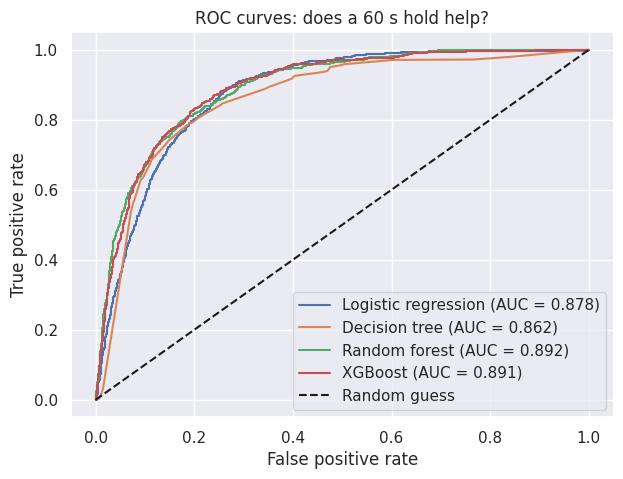

,Threshold,Validation F1,AUC,Recall,Precision,F1
Model,,,,,,
Random forest,0.55,0.741,0.892,0.755,0.668,0.709
XGBoost,0.35,0.737,0.891,0.867,0.593,0.705
Logistic regression,0.60,0.730,0.878,0.761,0.640,0.695
Decision tree,0.45,0.722,0.862,0.806,0.608,0.693


Best model: Random forest, threshold: 0.55


In [72]:
# The same compare_models as in section 4, now with the target 'hold_helps'
hold_results, hold_models = compare_models(hold_train, hold_test, 'hold_helps',
                                           title='ROC curves: does a 60 s hold help?',
                                           feature_list=hold_features)
display(hold_results.round(3))

best_hold = hold_results.index[0]
hold_model, hold_threshold = hold_models[best_hold]
print(f"Best model: {best_hold}, threshold: {hold_threshold:.2f}")

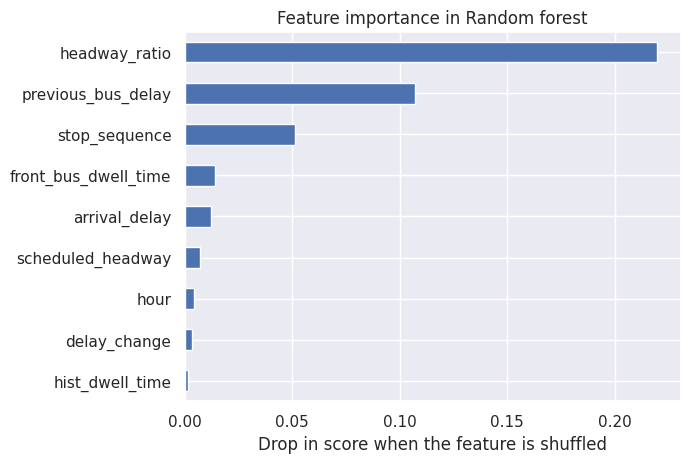

In [73]:
# Which features does the hold model use?
# On the VALIDATION days (the last 10 training days, not used to train the model)
val_days = sorted(hold_train['date'].unique())[-10:]
hold_val = hold_train[hold_train['date'].isin(val_days)]
X_val, y_val = hold_val[hold_features], hold_val['hold_helps']
perm_hold = permutation_importance(hold_model, X_val, y_val,
                                   scoring='average_precision', n_repeats=5, random_state=42)
pd.Series(perm_hold.importances_mean, index=hold_features).sort_values().plot(kind='barh')
plt.xlabel('Drop in score when the feature is shuffled')
plt.title(f'Feature importance in {best_hold}')
plt.show()

Bus-stops: train 119701, test 34971
A 60 s hold helps in 11.8 % of all bus-stops
  buses that are too close: 31.1 %
  buses that are NOT too close: 9.9 %


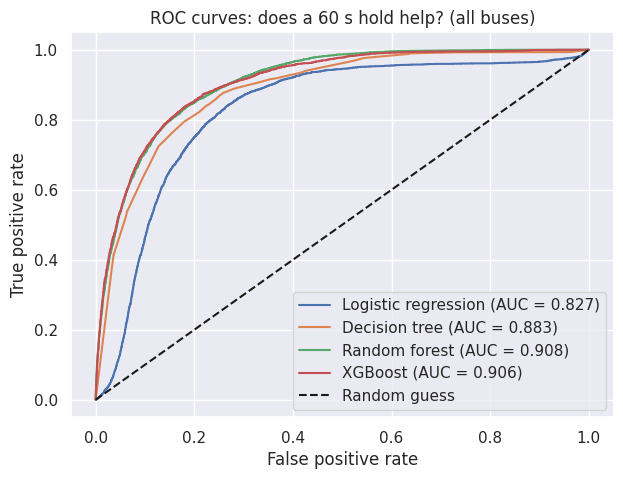

,Threshold,Validation F1,AUC,Recall,Precision,F1
Model,,,,,,
XGBoost,0.70,0.592,0.906,0.709,0.485,0.576
Random forest,0.65,0.583,0.908,0.668,0.503,0.574
Decision tree,0.80,0.545,0.883,0.539,0.523,0.531
Logistic regression,0.60,0.474,0.827,0.677,0.351,0.463


Best preventive model: XGBoost, threshold: 0.70


In [74]:
# Preventive hold model: does a 60 s hold help? Now for ALL buses at all stops,
# not only buses that are already too close (the reactive model above).
# Same target (hold_helps) and the same compare_models, but trained on every bus-stop.
prev_data = hv.dropna(subset=['headway_ratio']).copy()
prev_train = prev_data[~prev_data['date'].isin(test_dates)]
prev_test = prev_data[prev_data['date'].isin(test_dates)]
print(f"Bus-stops: train {len(prev_train)}, test {len(prev_test)}")
print(f"A 60 s hold helps in {prev_data['hold_helps'].mean() * 100:.1f} % of all bus-stops")
print(f"  buses that are too close: {prev_data.loc[prev_data['bunching'] == 1, 'hold_helps'].mean() * 100:.1f} %")
print(f"  buses that are NOT too close: {prev_data.loc[prev_data['bunching'] == 0, 'hold_helps'].mean() * 100:.1f} %")

# Compare all models (takes a few minutes: about 10 times more rows than the reactive model)
prev_results, prev_models = compare_models(prev_train, prev_test, 'hold_helps',
                                           title='ROC curves: does a 60 s hold help? (all buses)',
                                           feature_list=hold_features)
display(prev_results.round(3))

best_prev = prev_results.index[0]
prev_model, prev_threshold = prev_models[best_prev]
print(f"Best preventive model: {best_prev}, threshold: {prev_threshold:.2f}")

**The holding simulation**

`simulate` replays the test days stop by stop along the route and lets a holding rule decide which buses are held 60 s:

1. At every stop, each bus's simulated arrival time = its real arrival time + all holds at earlier stops.
2. From the simulated arrival times, the new gaps (headways) to the bus in front are calculated.
3. The features are updated with these simulated times, so an ML rule sees each bus's situation **after** all earlier holds.
4. The rule decides which buses are held here, and the hold is added to everything that bus does later on the route.
5. In the end, a bus-stop counts as bunched if its simulated gap is less than half the planned gap.

The results are then summarised as bunched bus-stops, holds and holding minutes per day.

In [75]:
def simulate(data, rule, hold=H):
    """Run a holding rule on the data, stop by stop. rule(X) returns True for the buses to hold."""
    # One entry per bus trip (date + trip_id): what has happened to this bus so far
    trip_keys = pd.MultiIndex.from_frame(data[['date', 'trip_id']].drop_duplicates())
    held_so_far = pd.Series(0.0, index=trip_keys)  # seconds held at earlier stops
    delay_last_stop = pd.Series(0.0, index=trip_keys)  # extra delay (from holds) at the previous stop
    ratio_last_stop = pd.Series(np.nan, index=trip_keys)  # simulated headway ratio at the previous stop
    results = []

    # Go stop by stop along the route
    for s in sorted(data['stop_sequence'].unique()):
        # All buses at this stop, in timetable order
        at_stop = data[data['stop_sequence'] == s].sort_values(
            ['date', 'scheduled_arrival_time_sfm']).copy()
        # How long each of these buses has been held before this stop
        key = pd.MultiIndex.from_frame(at_stop[['date', 'trip_id']])
        extra = held_so_far.reindex(key).values
        line = at_stop['date']  # buses on the same day

        # Simulated arrival = real arrival + all earlier holds, then the new gap to the bus in front
        at_stop['sim_arrival'] = at_stop['observed_arrival_time_sfm'] + extra
        at_stop['sim_headway'] = at_stop.groupby(line)['sim_arrival'].diff().abs()

        # The features, updated with the simulated times (the ML models see the situation after the holds)
        X = at_stop[features].copy()
        X['headway_ratio'] = at_stop['sim_headway'] / at_stop['scheduled_headway']
        X['arrival_delay'] = at_stop['arrival_delay'] + extra
        X['previous_bus_delay'] = X.groupby(line)['arrival_delay'].shift(1)
        X['upstream_stop_delay'] = at_stop['upstream_stop_delay'] + delay_last_stop.reindex(key).values
        X['delay_change'] = X['arrival_delay'] - X['upstream_stop_delay']
        X['front_bus_delay_change'] = X.groupby(line)['delay_change'].shift(1)
        X['front_bus_headway_ratio'] = X.groupby(line)['headway_ratio'].shift(1)
        X['headway_ratio_change'] = X['headway_ratio'] - ratio_last_stop.reindex(key).values

        # Ask the rule which buses are held here (hold seconds, 0 = not held)
        at_stop['hold_time'] = np.where(rule(X), hold, 0)
        at_stop['held'] = (at_stop['hold_time'] > 0).astype(int)

        # Remember for the next stops: delays, headway ratios and the total time held
        delay_last_stop.update(pd.Series(extra, index=key))
        ratio_last_stop.update(pd.Series(X['headway_ratio'].values, index=key))
        held_so_far = held_so_far.add(pd.Series(at_stop['hold_time'].values, index=key), fill_value=0)
        results.append(at_stop)

    # All stops together: a bus-stop is bunched if its simulated gap is less than half the planned gap
    sim = pd.concat(results).dropna(subset=['sim_headway'])
    sim['sim_bunching'] = (sim['sim_headway'] < 0.5 * sim['scheduled_headway']).astype(int)
    return sim

# The test days, used for the simulations
test_part = df_all[df_all['date'].isin(test_dates)]
n_test_days = len(test_dates)

,Bunched bus-stops per day,Holds per day,Holding (min per day),Bunching change (%),Bunching avoided per hour of holding
No holding,224.40,0.00,0.00,0.00,NaN
Rule-based: hold every bus that is too close (headway ratio < 0.5),86.47,86.47,86.47,-61.47,95.71
Reactive ML: hold if too close AND Random forest says the hold helps,111.07,50.73,50.73,-50.51,134.03
Preventive ML: hold ANY bus where XGBoost says the hold helps,49.87,393.60,393.60,-77.78,26.61


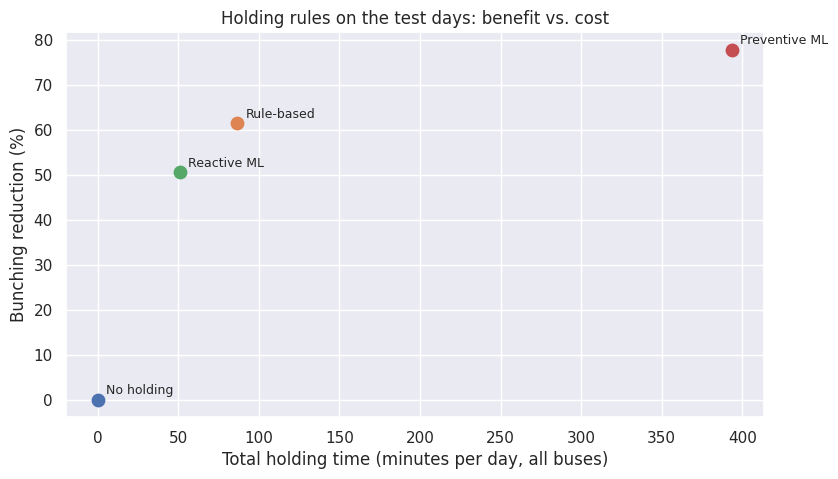

In [76]:
# The four holding rules. Each rule gets the features X of the buses at one stop
# and returns True for every bus that should be held there.

def no_holding(X):
    # Never hold a bus
    return np.zeros(len(X), dtype=bool)

def rule_based(X):
    # Hold every bus that is too close to the bus in front (headway ratio < 0.5)
    return (X['headway_ratio'] < 0.5).values

def reactive_ml(X):
    # Hold a bus that is too close, but only if the reactive model predicts that the hold helps
    too_close = (X['headway_ratio'] < 0.5).values
    hold_helps = hold_model.predict_proba(X[hold_features])[:, 1] >= hold_threshold
    return too_close & hold_helps

def preventive_ml(X):
    # Hold ANY bus where the preventive model predicts that the hold helps
    return prev_model.predict_proba(X[hold_features])[:, 1] >= prev_threshold

rules = {
    'No holding': no_holding,
    'Rule-based: hold every bus that is too close (headway ratio < 0.5)': rule_based,
    f'Reactive ML: hold if too close AND {best_hold} says the hold helps': reactive_ml,
    f'Preventive ML: hold ANY bus where {best_prev} says the hold helps': preventive_ml,
}

# Run every rule in the simulation on the test days
sim_results = {}
for name, rule in rules.items():
    sim = simulate(test_part, rule)
    # Bunched bus-stops, holds and holding minutes per day
    sim_results[name] = {'Bunched bus-stops per day': sim['sim_bunching'].sum() / n_test_days,
                         'Holds per day': sim['held'].sum() / n_test_days,
                         'Holding (min per day)': sim['hold_time'].sum() / 60 / n_test_days}
sim_results = pd.DataFrame(sim_results).T

# Compare with no holding
base = sim_results.loc['No holding', 'Bunched bus-stops per day']
sim_results['Bunching change (%)'] = (sim_results['Bunched bus-stops per day'] - base) / base * 100
sim_results['Bunching avoided per hour of holding'] = (
    (base - sim_results['Bunched bus-stops per day']) / (sim_results['Holding (min per day)'] / 60))
display(sim_results.round(2))

# Benefit vs. cost: up and to the left = more bunching avoided with less holding
plt.figure(figsize=(9, 5))
for name, row in sim_results.iterrows():
    plt.scatter(row['Holding (min per day)'], -row['Bunching change (%)'], s=80)
    plt.annotate(name.split(':')[0], (row['Holding (min per day)'], -row['Bunching change (%)']),
                 xytext=(6, 4), textcoords='offset points', fontsize=9)
plt.xlabel('Total holding time (minutes per day, all buses)')
plt.ylabel('Bunching reduction (%)')
plt.title('Holding rules on the test days: benefit vs. cost')
plt.show()

Validation days: 20241028 - 20241108


,Bunching change (%),Holding (min per day),Bunching avoided per hour of holding
Rule-based,-61.89,71.5,97.43
0.7,-84.49,384.0,24.77
0.8,-78.20,177.9,49.48
0.85,-77.45,112.1,77.77
0.9,-67.80,71.3,107.04
0.95,-39.98,27.5,163.64
0.97,-8.37,4.2,224.29


Chosen threshold (on the validation days): 0.9
Test days:


,Bunching change (%),Holding (min per day),Bunching avoided per hour of holding,Beats the rule-based hold,Chosen on validation days
0.7,-77.78,393.60,26.61,False,False
0.8,-76.59,211.00,48.87,False,False
0.85,-72.88,142.00,69.10,False,False
0.9,-67.91,83.53,109.47,True,True
0.95,-34.70,28.73,162.60,False,False
0.97,-8.38,5.80,194.48,False,False


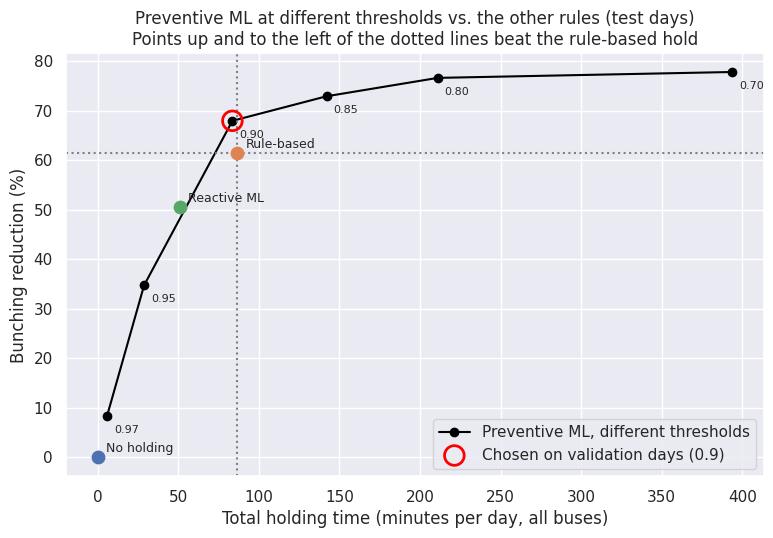

In [77]:
# Preventive ML with different thresholds.
# A higher threshold = the model holds a bus only when it is very sure that the hold helps
# (fewer holds). The threshold above (chosen by F1) treats a missed helpful hold and an
# unnecessary hold as equally bad, but in operation every unnecessary hold delays passengers.
#
# Step 1: CHOOSE the threshold on the validation days (the last 10 training days; the preventive
#         model was not trained on them). Rule: the largest bunching reduction among the
#         thresholds that need no more holding than the rule-based hold.
# Step 2: TEST all thresholds on the test days and mark the chosen one.
thresholds_sim = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97]

def preventive_rule(threshold):
    """A holding rule that holds a bus when the preventive model's probability is at least 'threshold'."""
    def rule(X):
        return prev_model.predict_proba(X[hold_features])[:, 1] >= threshold
    return rule

def run_rules(data):
    """Bunching reduction and holding per day for the rule-based hold and each preventive threshold."""
    n_days = data['date'].nunique()
    def summary(rule):
        s = simulate(data, rule)
        return s['sim_bunching'].sum() / n_days, s['hold_time'].sum() / 60 / n_days
    no_hold, _ = summary(no_holding)
    rows = {}
    for name, rule in [('Rule-based', rule_based)] + [(t, preventive_rule(t)) for t in thresholds_sim]:
        bunched, holding = summary(rule)
        rows[name] = {'Bunching change (%)': (bunched - no_hold) / no_hold * 100,
                      'Holding (min per day)': holding,
                      'Bunching avoided per hour of holding': (no_hold - bunched) / (holding / 60)}
    return pd.DataFrame(rows).T

# Step 1: validation days
train_dates = [d for d in dates if d not in test_dates]
val_sim_part = df_all[df_all['date'].isin(train_dates[-10:])]
val_curve = run_rules(val_sim_part)
val_rule = val_curve.loc['Rule-based']
val_prev = val_curve.drop('Rule-based')
ok = val_prev[val_prev['Holding (min per day)'] <= val_rule['Holding (min per day)']]
best_prev_t = ok['Bunching change (%)'].idxmin() if len(ok) else val_prev['Holding (min per day)'].idxmin()
print(f"Validation days: {val_sim_part['date'].min()} - {val_sim_part['date'].max()}")
display(val_curve.round(2))
print(f"Chosen threshold (on the validation days): {best_prev_t}")

# Step 2: test days
test_curve = run_rules(test_part)
prev_curve = test_curve.drop('Rule-based')
rule_row = test_curve.loc['Rule-based']
prev_curve['Beats the rule-based hold'] = (
    (prev_curve['Bunching change (%)'] < rule_row['Bunching change (%)'])
    & (prev_curve['Holding (min per day)'] < rule_row['Holding (min per day)']))
prev_curve['Chosen on validation days'] = prev_curve.index == best_prev_t
print('Test days:')
display(prev_curve.round(2))

# Trade-off curve of the preventive model on the test days, with the other rules as points
plt.figure(figsize=(9, 5.5))
plt.plot(prev_curve['Holding (min per day)'], -prev_curve['Bunching change (%)'], marker='o', color='black',
         label='Preventive ML, different thresholds')
chosen = prev_curve.loc[best_prev_t]
plt.scatter(chosen['Holding (min per day)'], -chosen['Bunching change (%)'], s=200, facecolors='none',
            edgecolors='red', linewidths=2, zorder=4, label=f'Chosen on validation days ({best_prev_t})')
for t, row in prev_curve.iterrows():
    plt.annotate(f'{t:.2f}', (row['Holding (min per day)'], -row['Bunching change (%)']),
                 xytext=(5, -12), textcoords='offset points', fontsize=8)
for name, row in sim_results.iterrows():
    if not name.startswith('Preventive'):
        plt.scatter(row['Holding (min per day)'], -row['Bunching change (%)'], s=80, zorder=3)
        plt.annotate(name.split(':')[0], (row['Holding (min per day)'], -row['Bunching change (%)']),
                     xytext=(6, 4), textcoords='offset points', fontsize=9)
plt.axhline(-rule_row['Bunching change (%)'], color='grey', linestyle=':')
plt.axvline(rule_row['Holding (min per day)'], color='grey', linestyle=':')
plt.xlabel('Total holding time (minutes per day, all buses)')
plt.ylabel('Bunching reduction (%)')
plt.title('Preventive ML at different thresholds vs. the other rules (test days)\n'
          'Points up and to the left of the dotted lines beat the rule-based hold')
plt.legend(loc='lower right')
plt.show()

# 6. Model diagnostics

How does the best bunching model from section 4 (bunched within 3 stops, `bunch_model` with `bunch_threshold`) work in different situations? Unless said otherwise, everything is measured on the 15 test days (11–29 November).

1. When and where does the model work, and where does it fail?
2. Does it generalize over months?
3. Is it fast enough to run in real time (scalability)?

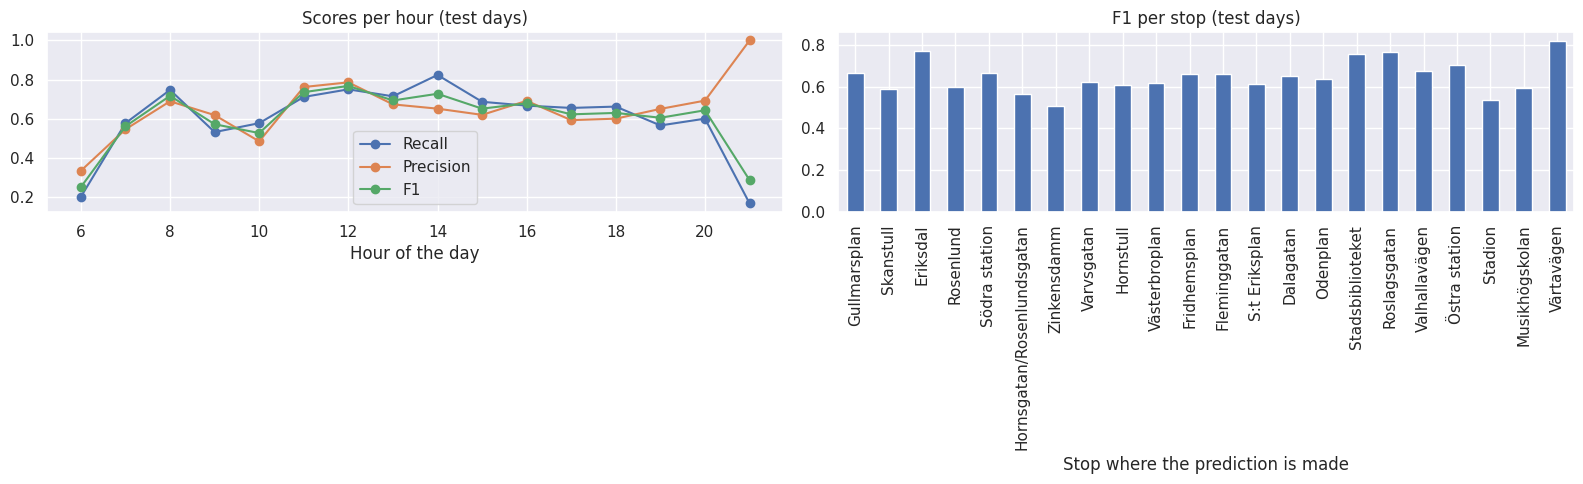

,Bunching cases,Recall,Precision,F1
hour,,,,
6,5.0,0.20,0.33,0.25
7,52.0,0.58,0.55,0.56
8,83.0,0.75,0.69,0.72
9,64.0,0.53,0.62,0.57
10,26.0,0.58,0.48,0.53
11,45.0,0.71,0.76,0.74
12,44.0,0.75,0.79,0.77
13,49.0,0.71,0.67,0.69
14,34.0,0.82,0.65,0.73


,Bunching cases,Recall,Precision,F1
stop_sequence,,,,
Gullmarsplan,32.0,0.72,0.62,0.67
Skanstull,26.0,0.58,0.60,0.59
Eriksdal,30.0,0.73,0.81,0.77
Rosenlund,35.0,0.69,0.53,0.60
Södra station,26.0,0.73,0.61,0.67
Hornsgatan/Rosenlundsgatan,28.0,0.54,0.60,0.57
Zinkensdamm,40.0,0.40,0.70,0.51
Varvsgatan,48.0,0.73,0.54,0.62
Hornstull,52.0,0.63,0.58,0.61


In [78]:
# Diagnostics 1: when and where does the model work? (test days)
# The stop is where the prediction is made; the bunching it predicts happens 3 stops later.
diag = ahead_test[['date', 'hour', 'stop_sequence', 'bunching_ahead']].copy()
X_test = ahead_test[features]
y_probs = bunch_model.predict_proba(X_test)[:, 1]
diag['pred'] = (y_probs >= bunch_threshold).astype(int)

def scores(g):
    return pd.Series({'Bunching cases': g['bunching_ahead'].sum(),
                      'Recall': recall_score(g['bunching_ahead'], g['pred'], zero_division=0),
                      'Precision': precision_score(g['bunching_ahead'], g['pred'], zero_division=0),
                      'F1': f1_score(g['bunching_ahead'], g['pred'], zero_division=0)})

per_hour = diag.groupby('hour')[['bunching_ahead', 'pred']].apply(scores)
per_stop = diag.groupby('stop_sequence')[['bunching_ahead', 'pred']].apply(scores)
per_stop.index = per_stop.index.map(stop_names_by_sequence)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
per_hour[['Recall', 'Precision', 'F1']].plot(marker='o', ax=axes[0])
axes[0].set_xlabel('Hour of the day')
axes[0].set_title('Scores per hour (test days)')
per_stop['F1'].plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Stop where the prediction is made')
axes[1].set_title('F1 per stop (test days)')
plt.tight_layout()
plt.show()

display(per_hour.round(2))
display(per_stop.round(2))

In [79]:
# Diagnostics 2: does the model generalize over months?
# The same model type, trained on different periods, always tested on the same November test days
periods = {
    'September only': ahead_train['date'] < 20241001,
    'October only': (ahead_train['date'] >= 20241001) & (ahead_train['date'] < 20241101),
    'All training days (2 Sep - 8 Nov)': ahead_train['date'] > 0,
}
rows = []
for name, mask in periods.items():
    res, _ = compare_models(ahead_train[mask], ahead_test, 'bunching_ahead', {best_ahead: bunch_model_type})
    rows.append({'Trained on': name, 'Training days': ahead_train.loc[mask, 'date'].nunique(),
                 **res.iloc[0].to_dict()})
display(pd.DataFrame(rows).set_index('Trained on').round(3))

# Is the performance stable from week to week? (model trained on all training days)
diag['week'] = pd.to_datetime(diag['date'].astype(str), format='%Y%m%d').dt.isocalendar().week.values
per_week = diag.groupby('week')[['bunching_ahead', 'pred']].apply(scores)
display(per_week.round(3))

,Training days,Threshold,Validation F1,AUC,Recall,Precision,F1
Trained on,,,,,,,
September only,21,0.8,0.604,0.979,0.680,0.596,0.635
October only,23,0.8,0.602,0.980,0.656,0.560,0.604
All training days (2 Sep - 8 Nov),50,0.9,0.634,0.982,0.662,0.641,0.651


,Bunching cases,Recall,Precision,F1
week,,,,
46,280.0,0.661,0.627,0.643
47,303.0,0.640,0.636,0.638
48,316.0,0.684,0.659,0.671


In [80]:
# Diagnostics 3: scalability (training and prediction time)
import time

# Training time on all training days
start = time.time()
model_s = clone(bunch_model_type)
if isinstance(model_s, XGBClassifier):
    model_s.fit(ahead_train[features], ahead_train['bunching_ahead'],
                sample_weight=compute_sample_weight('balanced', ahead_train['bunching_ahead']))
else:
    model_s.fit(ahead_train[features], ahead_train['bunching_ahead'])
train_seconds = time.time() - start

# Prediction time for all test rows at once
start = time.time()
bunch_model.predict_proba(ahead_test[features])
predict_seconds = time.time() - start

# Prediction time for one bus at a time (as in real time), averaged over 200 predictions
one_bus = ahead_test[features].iloc[[0]]
start = time.time()
for _ in range(200):
    bunch_model.predict_proba(one_bus)
one_bus_ms = (time.time() - start) / 200 * 1000

n_test_days = ahead_test['date'].nunique()
print(f"Training: {len(ahead_train)} rows in {train_seconds:.1f} s")
print(f"Prediction: {len(ahead_test)} rows in {predict_seconds:.2f} s")
print(f"One bus at a time: {one_bus_ms:.2f} ms per prediction")
print(f"Predictions per day on line 4 (northbound, 06-22): {len(ahead_test) / n_test_days:.0f}")
print(f"Prediction time per day if one bus at a time: {len(ahead_test) / n_test_days * one_bus_ms / 1000:.1f} s")

Training: 96518 rows in 2.2 s
Prediction: 27925 rows in 0.07 s
One bus at a time: 1.59 ms per prediction
Predictions per day on line 4 (northbound, 06-22): 1862
Prediction time per day if one bus at a time: 3.0 s
